# 03 - Training - Classical ML model (XGBoost)

Section **3.4 Training - Classical ML model** of the report.

## Brief

Classical ML model: justify the choice of algorithm and describe hyperparameters and the tuning process.

- Justify the algorithm choice (XGBoost or other).
- Initial hyperparameters and tuning process (grid / random / bayes).
- Validation strategy (CV, holdout).
- Persist the trained model to `models/` and metrics to `reports/`.

In [1]:
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import wandb
from dotenv import load_dotenv
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

from diplo_mod_1.constants import CONFIGS, MODELS, PROCESSED, RANDOM_STATE, REPORTS
from diplo_mod_1.domain.evaluate import evaluate_predictor
from diplo_mod_1.training import ModelRegistry, TuningHistory, XGBoostTuner, XGBoostTuningConfig

# override=True so re-running this cell after editing .env (without a kernel
# restart) always picks up the new values, instead of keeping whatever was
# already loaded into os.environ earlier in this kernel session.
load_dotenv(override=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Experiment tracking is opt-in: set WANDB_ENABLED=true (in .env or the shell)
# to log this run to Weights & Biases. Off by default so `poe check` / nbmake
# executions don't create a W&B run on every lint/test pass.
WANDB_ENABLED = os.environ.get("WANDB_ENABLED", "false").lower() == "true"

## Step 1 — Load processed dataset

Unscaled tabular features exported by notebook 02 (`data/processed/xgboost/`).

In [2]:
xgb_dir = PROCESSED / "xgboost"
X_train = np.load(xgb_dir / "X_train.npy")
X_val = np.load(xgb_dir / "X_val.npy")
X_test = np.load(xgb_dir / "X_test.npy")
y_train = np.load(xgb_dir / "y_train.npy")
y_val = np.load(xgb_dir / "y_val.npy")
y_test = np.load(xgb_dir / "y_test.npy")

feature_meta = json.loads((xgb_dir / "feature_names.json").read_text(encoding="utf-8"))
feature_names = feature_meta["feature_names"]

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Features: {len(feature_names)}")

X_train: (83180, 40), X_val: (20796, 40), X_test: (25995, 40)
Features: 40


## Step 2 — Baseline model

**Algorithm choice: XGBoost.** Gradient-boosted trees handle the mix of continuous, binary, and target-encoded features here without scaling, capture non-linear effects noted in EDA (e.g. the vintage-year U-shape), and are the standard strong baseline for tabular regression — a better fit than a linear model given the feature set built in notebook 02.

Untuned defaults first, to have a number the tuned model must beat.

In [3]:
tuning_config_name = os.environ.get("XGBOOST_TUNING_CONFIG", "xgboost_tuning.json")
tuning_config = XGBoostTuningConfig.from_json(CONFIGS / tuning_config_name)
print(f"Loaded tuning config: {tuning_config_name}")

# Computed once here and reused everywhere downstream (W&B run name, the
# model_filename in models/, and the run_id in reports/xgboost_metrics.json)
# so all three always point at the exact same run — no ambiguity about which
# W&B run produced which saved model.
run_id = f"{Path(tuning_config_name).stem}-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"

if WANDB_ENABLED:
    run_name = os.environ.get("WANDB_RUN_NAME") or f"xgboost-{run_id}"
    wandb.init(
        project=os.environ.get("WANDB_PROJECT", "diplo-mod-1"),
        name=run_name,
        group="xgboost-baseline",
        job_type="hpo",
        config={"tuning_config_name": tuning_config_name, **tuning_config.model_dump()},
    )

baseline = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_rmse = root_mean_squared_error(y_val, baseline_pred)
baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_r2 = r2_score(y_val, baseline_pred)
print(f"Baseline val RMSE: {baseline_rmse:.4f}")
print(f"Baseline val MAE:  {baseline_mae:.4f}")
print(f"Baseline val R2:   {baseline_r2:.4f}")

if WANDB_ENABLED:
    wandb.log(
        {
            "baseline_val_rmse": baseline_rmse,
            "baseline_val_mae": baseline_mae,
            "baseline_val_r2": baseline_r2,
        }
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Loaded tuning config: xgboost_tuning_wide_v3.json


wandb: Currently logged in as: leonardo-heis (leonardo-a-heis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Baseline val RMSE: 1.7028
Baseline val MAE:  1.3359
Baseline val R2:   0.6868


## Step 3 — Hyperparameter tuning (Optuna)

Bayesian search (TPE sampler) via `XGBoostTuner` (`src/diplo_mod_1/training/`), configured from a JSON file in `configs/` — default `xgboost_tuning.json`, override with the `XGBOOST_TUNING_CONFIG` env var (e.g. `XGBOOST_TUNING_CONFIG=xgboost_tuning_wide.json`) to try a different search space without touching code or overwriting the default file. Search-space bounds: `max_depth` (capped at 8 by default — deeper trees were the main overfit driver in the first pass), `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`, and regularization terms `reg_alpha`, `reg_lambda`, `gamma`. Each trial fits on `train` and scores RMSE against the held-out `val` split, with early stopping — `val` doubles as both the tuning objective and the early-stopping monitor, so `test` stays untouched until final evaluation.

In [4]:
def log_trial_to_wandb(study: optuna.Study, trial: optuna.trial.FrozenTrial) -> None:
    wandb.log({"trial": trial.number, "val_rmse": trial.value, **trial.params})


tuner = XGBoostTuner(tuning_config)
callbacks = [log_trial_to_wandb] if WANDB_ENABLED else None
study = tuner.tune(X_train, y_train, X_val, y_val, callbacks=callbacks)

print(f"Best val RMSE: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

if WANDB_ENABLED:
    wandb.log(
        {
            "best_val_rmse": study.best_value,
            **{f"best_{k}": v for k, v in study.best_params.items()},
        }
    )

  0%|          | 0/50 [00:00<?, ?it/s]

Best val RMSE: 1.6507
Best params: {'max_depth': 6, 'learning_rate': 0.0709748428220311, 'n_estimators': 1059, 'subsample': 0.7411428774887019, 'colsample_bytree': 0.7227821700985186, 'min_child_weight': 19, 'reg_alpha': 0.007153646280326323, 'reg_lambda': 0.006236039920397257, 'gamma': 1.813920329445381}


## Step 4 — Final model

Refit with `study.best_params`, same early-stopping setup, to pick the boosting round that generalizes best rather than the fixed `n_estimators` from the search.

In [5]:
best_model = tuner.fit_best(X_train, y_train, X_val, y_val, study)
print(f"Best iteration: {best_model.best_iteration}")

Best iteration: 1058


## Step 5 — Evaluate on train / val / test

In [6]:
splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
result = evaluate_predictor(best_model, splits, model_type="xgboost")

for m in result.metrics:
    print(f"{m.split:5s}  RMSE={m.rmse:.4f}  MAE={m.mae:.4f}  R2={m.r2:.4f}")
    if WANDB_ENABLED:
        wandb.log({f"{m.split}_rmse": m.rmse, f"{m.split}_mae": m.mae, f"{m.split}_r2": m.r2})

train  RMSE=1.3747  MAE=1.0711  R2=0.7952
val    RMSE=1.6507  MAE=1.2890  R2=0.7057
test   RMSE=1.6431  MAE=1.2808  R2=0.7086


## Step 6 — Feature importance

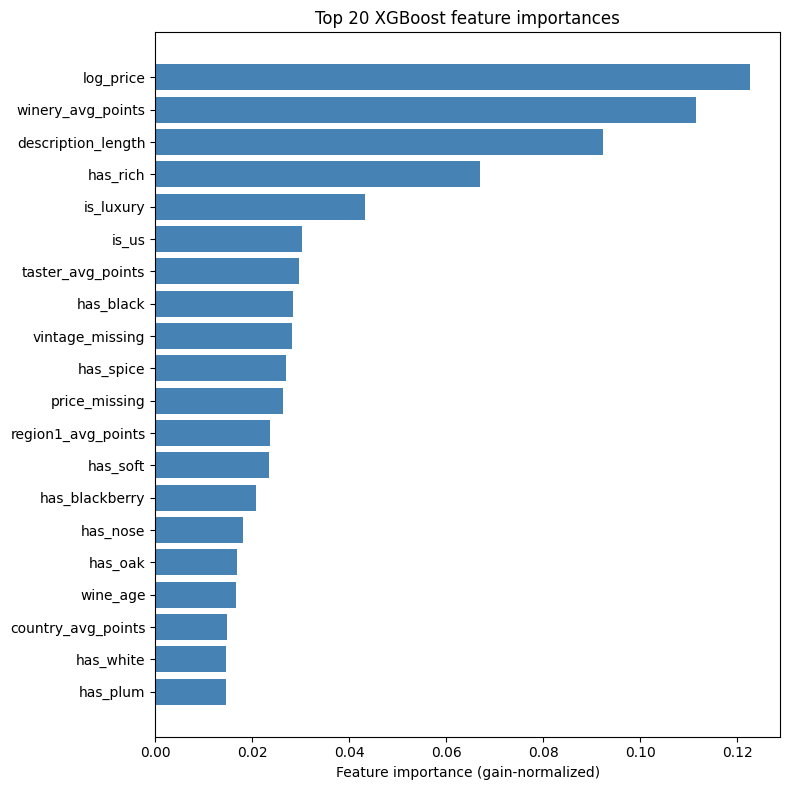

In [7]:
importances = best_model.feature_importances_
order = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh([feature_names[i] for i in order][::-1], importances[order][::-1], color="steelblue")
ax.set_xlabel("Feature importance (gain-normalized)")
ax.set_title("Top 20 XGBoost feature importances")
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"feature_importance": wandb.Image(fig)})

## Step 7 — Residual analysis

Residuals (`y_test - predicted`) for `best_model` on `test`: checks for heteroscedasticity (does error grow with the predicted score?), skew in the error distribution, and whether the model systematically over/under-predicts at specific `points` ranges. Run before Step 8 persists/closes the W&B run, so the plot gets logged too when `WANDB_ENABLED=true`.

Residual mean:   -0.0091  (0 = unbiased)
Residual std:    1.6431
Residual |max|:  7.9841


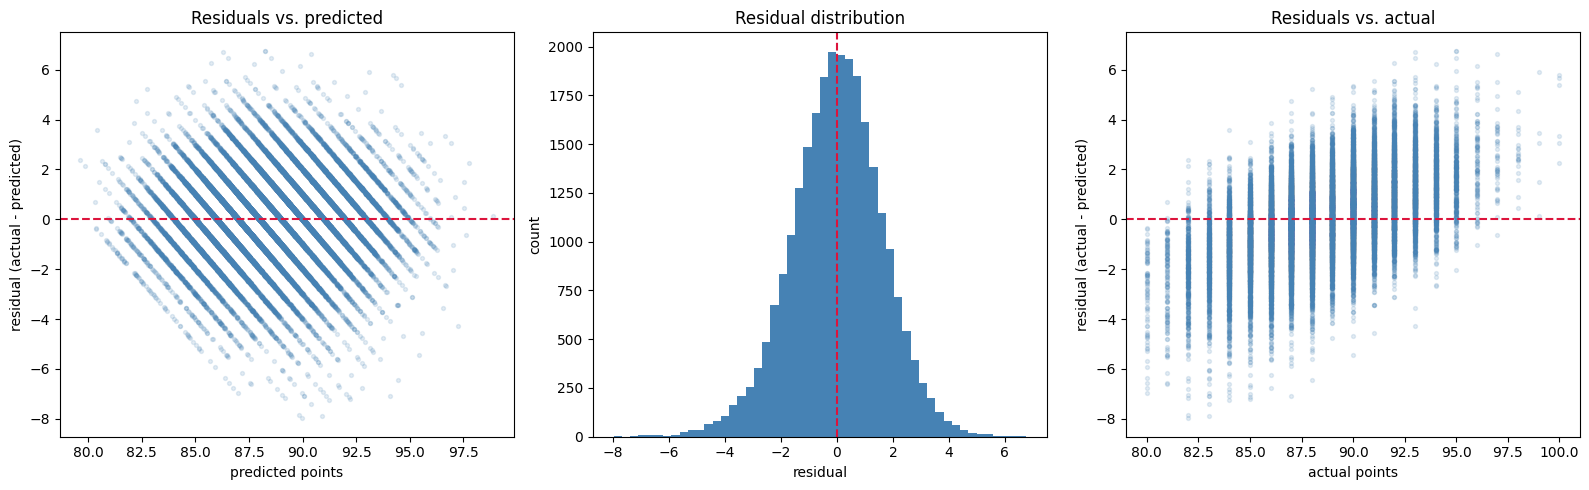

In [8]:
test_pred = best_model.predict(X_test)
residuals = y_test - test_pred

print(f"Residual mean:   {residuals.mean():.4f}  (0 = unbiased)")
print(f"Residual std:    {residuals.std():.4f}")
print(f"Residual |max|:  {np.abs(residuals).max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(test_pred, residuals, alpha=0.15, s=8, color="steelblue")
ax.axhline(0, color="crimson", lw=1.5, linestyle="--")
ax.set_xlabel("predicted points")
ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Residuals vs. predicted")

ax = axes[1]
ax.hist(residuals, bins=50, color="steelblue")
ax.axvline(0, color="crimson", lw=1.5, linestyle="--")
ax.set_xlabel("residual")
ax.set_ylabel("count")
ax.set_title("Residual distribution")

ax = axes[2]
ax.scatter(y_test, residuals, alpha=0.15, s=8, color="steelblue")
ax.axhline(0, color="crimson", lw=1.5, linestyle="--")
ax.set_xlabel("actual points")
ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Residuals vs. actual")

plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"residual_analysis": wandb.Image(fig)})

## Step 8 — Persist model and metrics

`ModelRegistry` (`src/diplo_mod_1/training/registry.py`) versions every run instead of overwriting: each run's checkpoint is saved as `models/xgboost_<run_id>.joblib`, and `models/xgboost_best.joblib` always points at whichever run has the lowest **test**-split RMSE on record — so nothing is lost when trying a different `configs/*.json` search space, and there's an explicit pointer to the current winner. `reports/xgboost_metrics.json` holds the full `{run_id, tuning_config, best_params, metrics}` history plus `best_run_id`, consumed by notebook 05 for the model comparison. If `WANDB_ENABLED=true`, the same run also has the search-space config, every Optuna trial, baseline metrics, final train/val/test metrics, the feature-importance plot, the residual-analysis plot, and the model checkpoint itself (as a W&B artifact) logged to Weights & Biases (project from `WANDB_PROJECT`, default `diplo-mod-1`; run name from `WANDB_RUN_NAME`, default auto-generated from the tuning config).

In [9]:
run_record, history = ModelRegistry.save_run(
    MODELS,
    REPORTS / "xgboost_metrics.json",
    best_model,
    run_id,
    tuning_config_name,
    study.best_params,
    result,
)

print(f"Model saved to {MODELS / run_record.model_filename}")
print(f"Best run so far: {history.best_run_id} -> models/xgboost_best.joblib")
print(f"Metrics appended to reports/xgboost_metrics.json ({len(history.runs)} run(s) on record)")

if WANDB_ENABLED:
    artifact = wandb.Artifact("xgboost_model", type="model")
    artifact.add_file(str(MODELS / run_record.model_filename))
    wandb.log_artifact(artifact)
    wandb.finish()

Model saved to ..\models\xgboost_tuning_wide_v3-20260729T200239Z.joblib
Best run so far: xgboost_tuning_wide_v2-20260729T030927Z -> models/xgboost_best.joblib
Metrics appended to reports/xgboost_metrics.json (4 run(s) on record)


baseline_val_mae,▁
baseline_val_r2,▁
baseline_val_rmse,▁
best_colsample_bytree,▁
best_gamma,▁
best_learning_rate,▁
best_max_depth,▁
best_min_child_weight,▁
best_n_estimators,▁
best_reg_alpha,▁
+22,...


## Step 9 — Compare all XGBoost runs

Every run recorded in `reports/xgboost_metrics.json` (across all `configs/*.json` search spaces tried), side by side. The winning row matches `models/xgboost_best.joblib`.

In [10]:
history_path = REPORTS / "xgboost_metrics.json"
all_runs = TuningHistory.model_validate_json(history_path.read_text(encoding="utf-8"))

comparison = pd.DataFrame(
    [
        {
            "run_id": r.run_id,
            "tuning_config": r.tuning_config,
            "train_r2": next(m.r2 for m in r.metrics if m.split == "train"),
            "train_mae": next(m.mae for m in r.metrics if m.split == "train"),
            "train_rmse": next(m.rmse for m in r.metrics if m.split == "train"),
            "test_r2": next(m.r2 for m in r.metrics if m.split == "test"),
            "test_rmse": next(m.rmse for m in r.metrics if m.split == "test"),
            "test_mae": next(m.mae for m in r.metrics if m.split == "test"),
            "val_r2": next(m.r2 for m in r.metrics if m.split == "val"),
            "val_rmse": next(m.rmse for m in r.metrics if m.split == "val"),
            "val_mae": next(m.mae for m in r.metrics if m.split == "val"),
            "is_best": r.run_id == all_runs.best_run_id,
        }
        for r in all_runs.runs
    ]
).sort_values("test_r2", ascending=False)

comparison

,run_id,tuning_config,train_r2,train_mae,train_rmse,test_r2,test_rmse,test_mae,val_r2,val_rmse,val_mae,is_best
2,xgboost_tuning_wide_v2-20260729T030927Z,xgboost_tuning_wide_v2.json,0.959789,0.444780,0.609151,0.720736,1.608452,1.239931,0.718843,1.613349,1.248701,True
1,xgboost_tuning_wide-20260729T030243Z,xgboost_tuning_wide.json,0.895892,0.741621,0.980150,0.714954,1.625016,1.259570,0.713466,1.628704,1.264333,False
0,xgboost_tuning-20260729T025351Z,xgboost_tuning.json,0.841297,0.933759,1.210162,0.711803,1.633974,1.271129,0.708276,1.643389,1.282545,False
3,xgboost_tuning_wide_v3-20260729T200239Z,xgboost_tuning_wide_v3.json,0.795220,1.071073,1.374656,0.708559,1.643143,1.280771,0.705656,1.650750,1.289019,False


## Design notes (report)

**Algorithm choice:** XGBoost — handles the mixed continuous/binary/target-encoded feature matrix from notebook 02 without scaling, and captures non-linear relationships (e.g. the vintage-year U-shape found in EDA) that a linear baseline cannot.

**Tuning process:** Bayesian optimization via Optuna (TPE sampler), configured from `configs/*.json` (selectable via `XGBOOST_TUNING_CONFIG`) and run through the reusable `XGBoostTuner` class (`src/diplo_mod_1/training/`) rather than inline in the notebook — mirrors the `DataCleaner`/`FeatureEngineer`/`TabularEncoder` pattern from notebook 02. Each trial uses early stopping against `val` rather than a fixed boosting-round count, so the search jointly tunes regularization-style parameters and training length.

**Validation strategy:** holdout, not k-fold CV — reuses the stratified `train`/`val`/`test` split from notebook 02. `val` drives both the Optuna objective and early stopping; `test` is touched only once, for the final reported metrics (via `evaluate_predictor`, shared with notebook 04 through the `WineScorePredictor` protocol), keeping it a fair held-out estimate for the notebook 05 comparison against the neural network.

**Persistence:** every run's model checkpoint is versioned (`models/xgboost_<run_id>.joblib`, via `ModelRegistry`), with `models/xgboost_best.joblib` always pointing at the run with the lowest test RMSE recorded so far. `reports/xgboost_metrics.json` accumulates the full run history (`ModelMetrics`/`EvaluationResult`, existing domain schemas) rather than overwriting, so multiple search-space experiments stay comparable side by side. Optionally the full run (config, trials, metrics, plot, model artifact) also goes to Weights & Biases when `WANDB_ENABLED=true`.